**Customer Churn Analysis And Tenure prediction Project**

Primary objective: developin end to end predictive data pipeline that can assist identify high risk customers based on tenure which can idirectly inform about  customer Churn before they  cancel a service, enabling targeted marketing   intervention to reduce campany revenue loss.

kind Note that the data only contains churned customers only

In [1]:
#Stepp 1 :Loading Data and Libraries
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# 1.1 Important libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt




In [2]:
import os

# Base directory (your main DS_DATA_PROJECTS folder)
base_dir = "DS_DATA_PROJECTS"

# Alternative path to Customer_Churn folder
customer_churn_path = os.path.join(base_dir, "Customer_Churn")

# Path to the dataset
dataset_path = os.path.join(customer_churn_path, "telecom_churn.csv")

print(dataset_path)

DS_DATA_PROJECTS\Customer_Churn\telecom_churn.csv


In [3]:
#1.2 Load dataset
df = pd.read_csv("telecom_churn.csv")

# Explore the dataset
df.head()



,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security
0,17267,female,0,No,Yes,41.0,Yes,Yes,Fiber optic,Yes
1,9242,Female,0,Yes,No,27.0,Yes,Yes,Fiber optic,Yes
2,19107,Male,1,Yes,Yes,36.0,Yes,Yes,DSL,No
3,8986,Female,0,No,No,1.0,N,N,No,No
4,2867,Male,0,No,Yes,20.0,Yes,Yes,fiber,No


In [4]:
#2 DATA Inspection and Query


#2.1 Data inspection length,data types.features and ispect for missing values

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20030 entries, 0 to 20029
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       20030 non-null  int64  
 1   gender            20030 non-null  str    
 2   senior_citizen    20030 non-null  str    
 3   partner           20030 non-null  str    
 4   dependents        20030 non-null  str    
 5   tenure            19958 non-null  float64
 6   phone_service     20030 non-null  str    
 7   multiple_lines    20030 non-null  str    
 8   internet_service  20030 non-null  str    
 9   online_security   20030 non-null  str    
dtypes: float64(1), int64(1), str(8)
memory usage: 1.5 MB


#Data Dictionary
 0   customer_id      -the id/unic token associated with the subscriber's account
 1   gender            -ndicates if the individual is afemale or male( for behavioral trends)
 2   senior_citizen    -indicates the age demographic customer belongs to (taylored services for older persons)  
 3   partner           -indecates  if the customer is married or not (may be in multi-line plans  ) 
 4   dependents        -indicates if customer has children ( possibly influence data usage patterns..)
 5   tenure            -Length of time the customer has been with the Network Provider
 6   phone_service     -indication of which service the  customer  has landline or cellular voce plan  
 7   multiple_lines    -Tracks if the consumer has more than one active number under their account  
 8   internet_service  - The type of connection infrastructure the customer uses (DSL,Fiber Optic,..)
 9   online_security    - Add on  cybersecurity services (fire walls, antiphishing software),relevance they  increase the cost for the customer to move decreasing the risk of the customer canceling their subscription. 


In [5]:
#2.1.1The data Quality analysis
#a. look for any missing values,hoh many are they relative to the data length
print(round(df.isnull().sum()/len(df),3)*100) #the nulls in the Tenure are 0,4% which is insignifcant and can be imputed

#b. look for any duplicates
print("The number of duplicated rows = ",df.duplicated().sum())
print("The number of unique ID =",df["customer_id"].nunique()) 

### Just an intrestig thing about telecommunication data  the subscriber id may be the same but as long as there is a column which is different
### The row is not a duplicate so it is looking for exact match not similarity when the computer is performing the task just a fun discovery
###please continue

#Dropping the duplicates to prevent leakage and ensure model evaluations have good mathematical precision
df_clean=df.drop_duplicates()

#inspect duplicates in the new data
print("No duplicates,",df_clean.duplicated().sum())
df_clean.shape


customer_id         0.0
gender              0.0
senior_citizen      0.0
partner             0.0
dependents          0.0
tenure              0.4
phone_service       0.0
multiple_lines      0.0
internet_service    0.0
online_security     0.0
dtype: float64
The number of duplicated rows =  30
The number of unique ID = 20000
No duplicates, 0


(20000, 10)

In [6]:
#2.1.1 The data Quality analysis
#c.Inspecting  cardnality of each  column or feature
#key note customer id has maximum cardinality there for it will be dropped at the  later in model training
for col in df_clean:
    if df_clean[col].nunique()<10:
        print(f"{col}:{df_clean[col].nunique()} unique values, namely :{df_clean[col].unique()}")
    else:
        print(f"{col}:{df_clean[col].nunique()} unique values")


customer_id:20000 unique values
gender:6 unique values, namely :<StringArray>
['female', 'Female', 'Male', 'F', 'M', 'male']
Length: 6, dtype: str
senior_citizen:4 unique values, namely :<StringArray>
['0', '1', 'Yes', 'No']
Length: 4, dtype: str
partner:4 unique values, namely :<StringArray>
['No', 'Yes', 'Y', 'N']
Length: 4, dtype: str
dependents:4 unique values, namely :<StringArray>
['Yes', 'No', 'N', 'Y']
Length: 4, dtype: str
tenure:138 unique values
phone_service:4 unique values, namely :<StringArray>
['Yes', 'N', 'No', 'Y']
Length: 4, dtype: str
multiple_lines:5 unique values, namely :<StringArray>
['Yes', 'N', 'No', 'Y', 'No phone service']
Length: 5, dtype: str
internet_service:5 unique values, namely :<StringArray>
['Fiber optic', 'DSL', 'No', 'fiber', 'Dsl']
Length: 5, dtype: str
online_security:5 unique values, namely :<StringArray>
['Yes', 'No', 'No internet service', 'Y', 'N']
Length: 5, dtype: str


*There are MORE THAN 2 ANSWERS FOR THE SAME RESPONSE  for good practice must ensure 1 responce that gives 1 form of information ge. if "f","F","female" at all cases is seen as Female

In [7]:
#c Data inspection and cleaning
#fixing the gender column to only have "Female" or "Male" values
df_clean["gender"]=df_clean["gender"].replace(("female","F"),"Female").replace(("male","M"),"Male")
print("gender",df_clean["gender"].unique())

#Fixing senior_citizen clumn to only have "Yes" or "No" responses
df_clean["senior_citizen"]=df_clean["senior_citizen"].replace("1","Yes").replace("0","No")
print("senior_citizen",df_clean["senior_citizen"].unique())

#Fixing the internet_service column  to only have Fibre optic,DSL or No internet service
df_clean["internet_service"]=df_clean["internet_service"].replace("Dsl","DSL").replace("fiber","Fiber optic").replace("No","No internet_service")
print("internet_service",df_clean["internet_service"].unique())

#
col_messy=["partner","dependents","phone_service","multiple_lines","online_security"]

for feature in col_messy:
     df_clean[feature]=df_clean[feature].replace("N","No").replace("Y","Yes")
     print(f"{feature}:{df_clean[feature].unique()}")

gender <StringArray>
['Female', 'Male']
Length: 2, dtype: str
senior_citizen <StringArray>
['No', 'Yes']
Length: 2, dtype: str
internet_service <StringArray>
['Fiber optic', 'DSL', 'No internet_service']
Length: 3, dtype: str
partner:<StringArray>
['No', 'Yes']
Length: 2, dtype: str
dependents:<StringArray>
['Yes', 'No']
Length: 2, dtype: str
phone_service:<StringArray>
['Yes', 'No']
Length: 2, dtype: str
multiple_lines:<StringArray>
['Yes', 'No', 'No phone service']
Length: 3, dtype: str
online_security:<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str


In [8]:
#2.1.1 The data Quality analysis
#d.Identifying impossible values
print(f"{(df_clean["tenure"]<0).sum()} number of customers have not been with the network provider")

0 number of customers have not been with the network provider


**Customer Churn : EXPLORITORY ANALYSIS** 
**GENERAL ANALYSIS- BIGGER PICTURE**

gender
Female    10052
Male       9948
Name: count, dtype: int64
key Note : the total number of entries are 20000


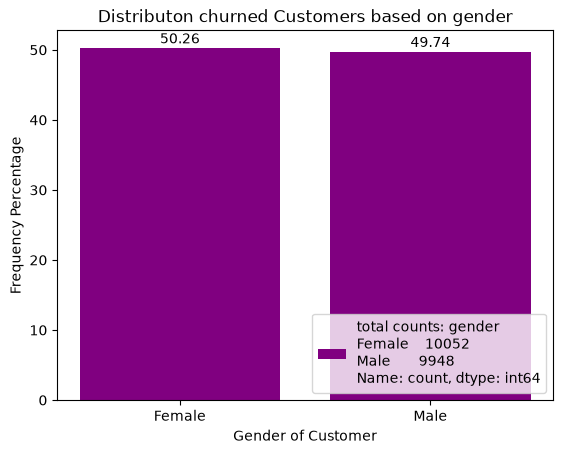

In [9]:
#Include the exact counts of the distribution
print((df_clean["gender"]).value_counts())
print(f"key Note : the total number of entries are {len(df_clean)}")
#BAR PLOTS WHCH SHOWS THE PERCENTAGE OF CHURNED CUSTOMERS BASED ON GENDER
bars=plt.bar(df_clean['gender'].unique(), ((df_clean['gender'].value_counts())/len(df_clean))*100, color='purple')
plt.xlabel("Gender of Customer")
plt.ylabel("Frequency Percentage")
plt.title("Distributon churned Customers based on gender")

plt.bar_label(bars, padding=1)
plt.legend(loc="lower right", labels=[f"total counts: {(df_clean['gender'].value_counts())}"])
plt.show()

**The above illastration shows the distribution of the Customers that cancelled thier subscription with the Telecom network based on the above Female customers have a higher rate of churn compared to male customers,but 50% female portion and  49.7% male portion is not significant.This indicates that  the gender is not the best feature for good prediction.The small difference may indicate hidden patterns of behaviors from the separate Genders.**

senior_citizen
No     16036
Yes     3964
Name: count, dtype: int64
key Note : the total number of entries are 20000


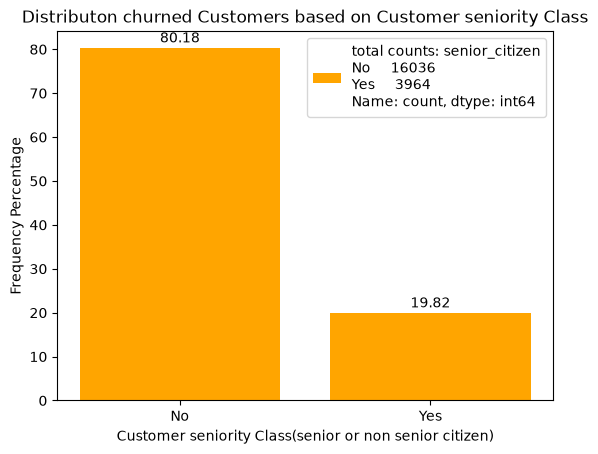

In [10]:
#Include the exact counts of the distribution
print((df_clean["senior_citizen"]).value_counts())
print(f"key Note : the total number of entries are {len(df_clean)}")
#BAR PLOTS WHCH SHOWS THE PERCENTAGE OF CHURNED CUSTOMERS BASED ON WHEATHER THE CUSTOMERS WERE SENIOR CITIZENS OR NOT
bars=plt.bar(df_clean['senior_citizen'].unique(), ((df_clean['senior_citizen'].value_counts())/len(df_clean))*100, color='orange')
plt.xlabel("Customer seniority Class(senior or non senior citizen)")
plt.ylabel("Frequency Percentage")
plt.title("Distributon churned Customers based on Customer seniority Class")

plt.bar_label(bars, padding=2)
plt.legend(loc="upper right", labels=[f"total counts: {(df_clean['senior_citizen'].value_counts())}"])
plt.show()

**The above Distributon churned Customers based on Customer seniority Class illastration shows off all the customers that cancelled their subcription wth the network about 80%  of them are not senior citizens and the remaining 20% are senior citizens.This means senior citizens are likely to not change network and may provide stable revanue for the network but majority of the Customers that use the network are not senor citizens there for measures to retain them should  be in place like promotions based on the a age groups and what services they use most.Due to the presence the strong skew between Senior citizens and non-senior citizens  and might be a good tenure predictor.**

***key questions arise from this analysis: Why young customers higly likely to churn or cancel their subscription?***
***since they are less likely to churn when they do , Why would they churn?
Will explore this in later stages.***
**These are the exact counts : senior(No     16036
Yes     3964)**


internet_service
Fiber optic            7974
DSL                    7918
No internet_service    4108
Name: count, dtype: int64
key Note : the total number of entries are 20000


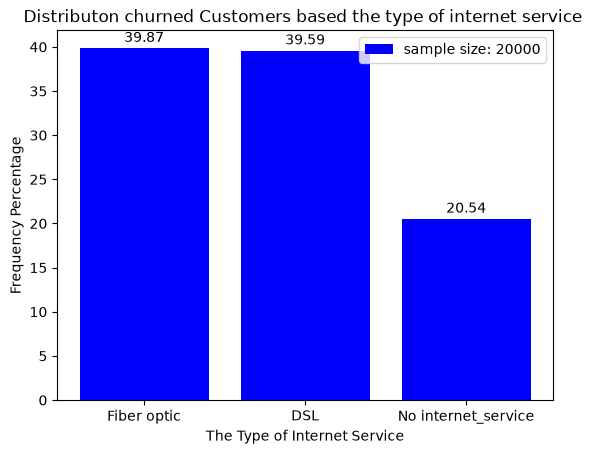

In [11]:
#Include the exact counts of the distribution
print((df_clean["internet_service"]).value_counts())
print(f"key Note : the total number of entries are {len(df_clean)}")


#BAR PLOTS WHCH SHOWS THE PERCENTAGE OF CHURNED CUSTOMERS BASED ON INTERNET SERVICE RENDERED BY THE NETWORK
bars=plt.bar(df_clean['internet_service'].unique(), ((df_clean['internet_service'].value_counts())/len(df_clean))*100, color='Blue')
plt.xlabel("The Type of Internet Service")
plt.ylabel("Frequency Percentage")
plt.title("Distributon churned Customers based the type of internet service ")

plt.bar_label(bars, padding=2)
plt.legend(loc="upper right", labels=[f"sample size: {(df_clean.shape[0])}"])
plt.show()

**Figure 3: Distributon churned Customers based the type of internet service shows that 39.9% of the customers who left used fiber optic internet service and similarly 39.6% used the DSL internet service  while only 20% did not use internet service.  About 80 % of the customers that left used internet service from the the Network.This may imply that Most of the Customers left due to matters related to the internet services.Marketing strategies would be to offer compettive, taylored internet services , with more informaatiomn interms of internet service feedbacks from customers to get to the bottom of issue.Some with no internet also may have churned due to other reasons which will be analysed atthe later stage.Can promote thier prefered service and internet add ons and rewads to promote utalisation and stickiness of customer.e.g minutes and data,cybersecurity and data,fiber with more data,when they pay for a subscrption add a reward.this may be a good feature for the tenure predicton model**

***big questions from this figure:we do not have more information on fiber an dsl but we can use the data set to UNDERSTAND Why do no  internet service subscribers churn? will analyse this in later stage***

multiple_lines
Yes                 9032
No                  6993
No phone service    3975
Name: count, dtype: int64
key Note : the total number of entries are 20000


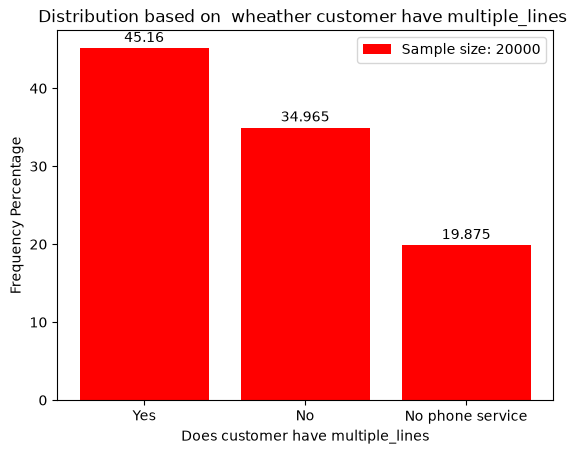

In [12]:

#Include the exact counts of the distribution
print((df_clean["multiple_lines"]).value_counts())
print(f"key Note : the total number of entries are {len(df_clean)}")
#BAR PLOTS WHCH SHOWS THE PERCENTAGE OF CHURNED CUSTOMERS BASED ON WHEATHER THE CUSTOMER HAD MULTIPLE LINES i.e they have more than one number in ther account
bars=plt.bar(df_clean['multiple_lines'].unique(), ((df_clean['multiple_lines'].value_counts())/len(df_clean))*100, color='Red')
plt.xlabel("Does customer have multiple_lines")
plt.ylabel("Frequency Percentage")
plt.title("Distribution based on  wheather customer have multiple_lines ")

plt.bar_label(bars, padding=2)
plt.legend(loc="upper right", labels=[f"Sample size: {(df_clean.shape[0])}"])
plt.show()

**Figure 4: According to the above illastration (Distribution based on  wheather customer have multiple_lines)  that shows the percentages of customers that left the network based on weather they had multiple lines (more than one number attached to thier account).About 45% of the customers that stopped using the network's services had multiple lines (numbers) which implies that even though the customer with multiple lines would be expected to have higherlevel of dependency on the network compared to single line,they cjhurn at much higer rates than expected so predicting understanding why they churn is a more complex question will be explored but bare inmid the level of anlysis is limited by the information present.About 35% of the customers left had only single line as to why the churn it could be that there s low dependancy on the network but  further anlysis is required as to why they left which may be a factor contributed by the network in anyway and how to mitigate that. While 20% of the Customers that left  had no phone service.The oones with no phone service realy on other services offered by the network - data/internet/ security services there most likely due to dissatsfaction with the products or packages but will invwestigate .**

***Big Questions :***
***-Why do multiple line customers churn that can be explained from the present data?***
***-Why do single  line customers churn  other than low dependency on the network?***
***-Why do the No phone service churn is it inernet dissatisfaction is it fier,dsl orthe security packages provided by the network***


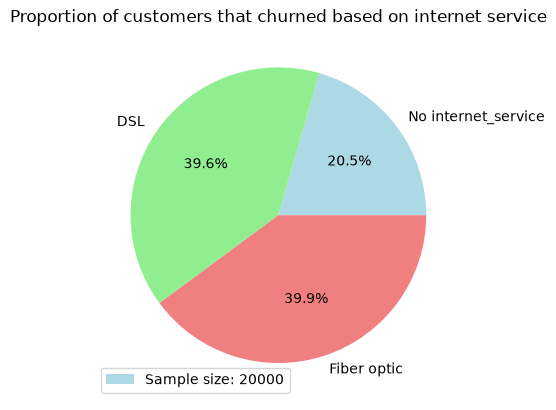

In [13]:
#Pie chart representing the proportions in percentages in the internet_service column
df_clean["internet_service"].value_counts(normalize=True).sort_values(ascending=True).plot(kind="pie",
colors=['lightblue', 'lightgreen', 'lightcoral'], autopct='%1.1f%%',
 title="Proportion of customers that churned based on internet service");
plt.legend(loc="lower left", labels=[f"Sample size: {(df_clean.shape[0])}"])

**figure 5:illastrates the percentage distribution of the Customers based on the  internet service.20.5% of the customers that churned had noo internet service which ndicates that they left due to reasons that are not related to the internet services (i.e.pricing,service dissatisfaction,irelevant telecommunication products).The 80% that left may have had problems with the internet service , further zoom in more left possibly due to fiber (39.6%) related issues while the other (39.9%) was due to DSL related problems or dissatisfaction.**

**key insights :**
**marketing strategies should include providing relevant products based on customer profile,combining internet and other services packages.**
**Both fiber and DSL technologies are contributing to customer churn**
**Internet service may be a great atenure predictor**

***Big Questions:***
***Why Fiber or DSL customers may have churned from the data present and for a proper and deeper analysis more information is reguired abouut the network fiber or dsl sevices ,Critical  area of investigation due to high number of customers leaving***

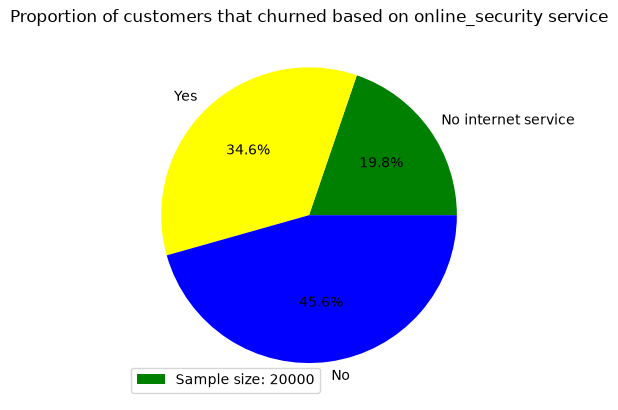

In [14]:
##Pie chart representing the proportions in percentages in the online_security column
df_clean["online_security"].value_counts(normalize=True).sort_values(ascending=True).plot(kind="pie",
colors=['green', 'yellow', 'blue'], autopct='%1.1f%%',
 title="Proportion of customers that churned based on online_security service");
plt.legend(loc="lower left", labels=[f"Sample size: {(df_clean.shape[0])}"])

**figure 6:Distribution of the churned customers based on online sercurity services.

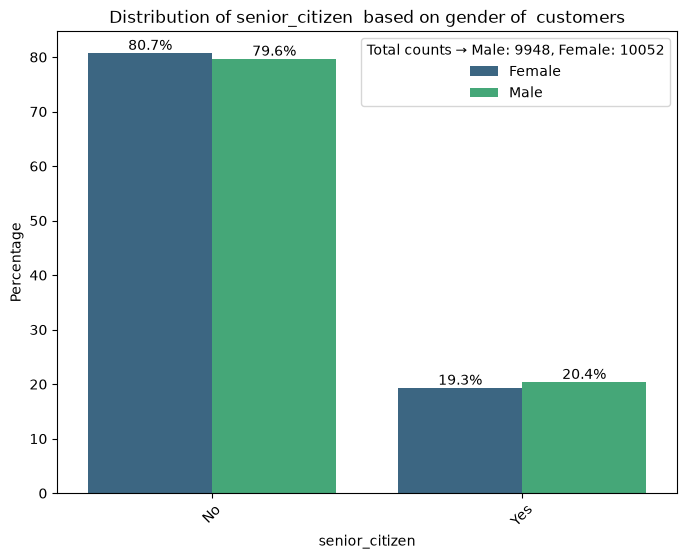

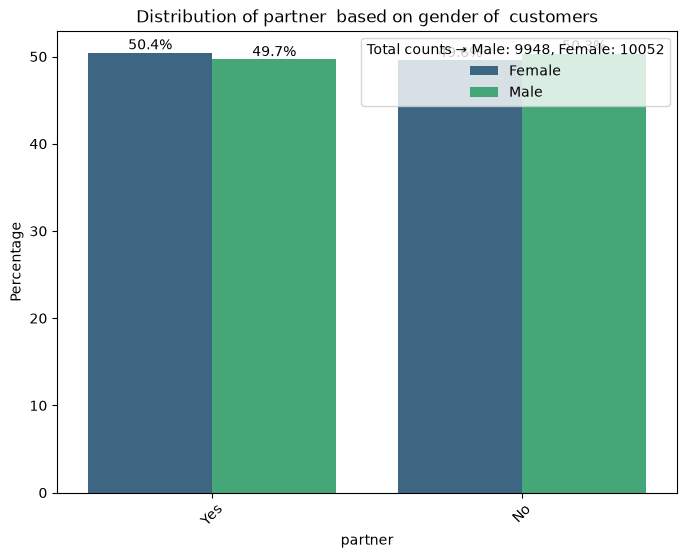

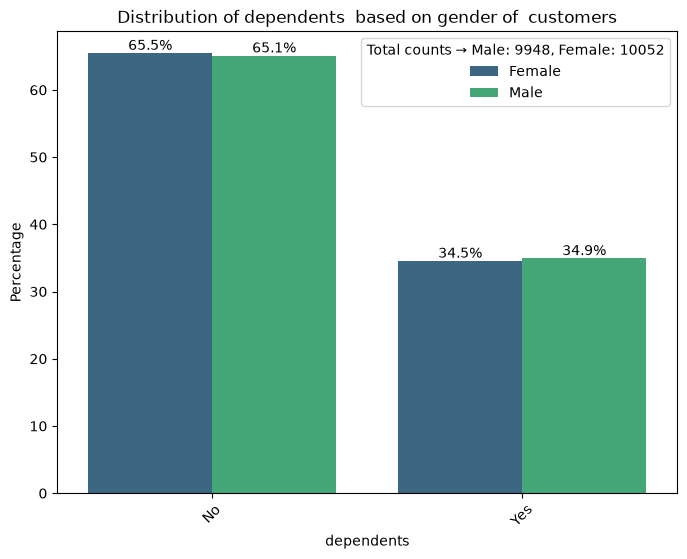

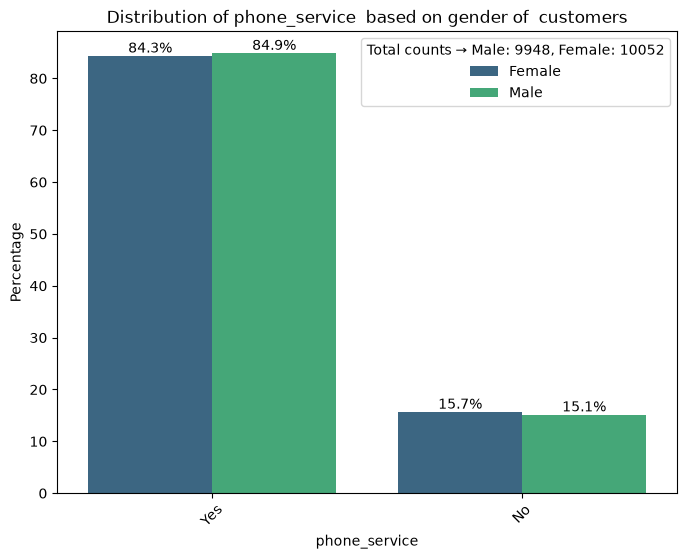

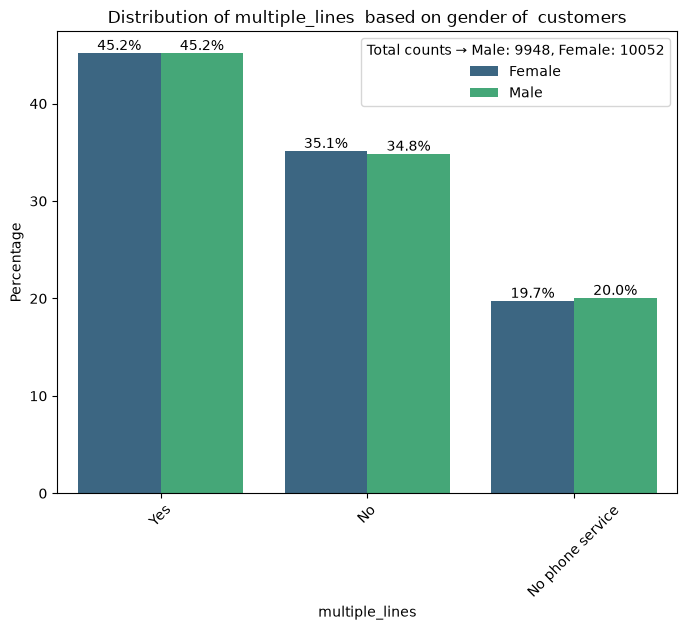

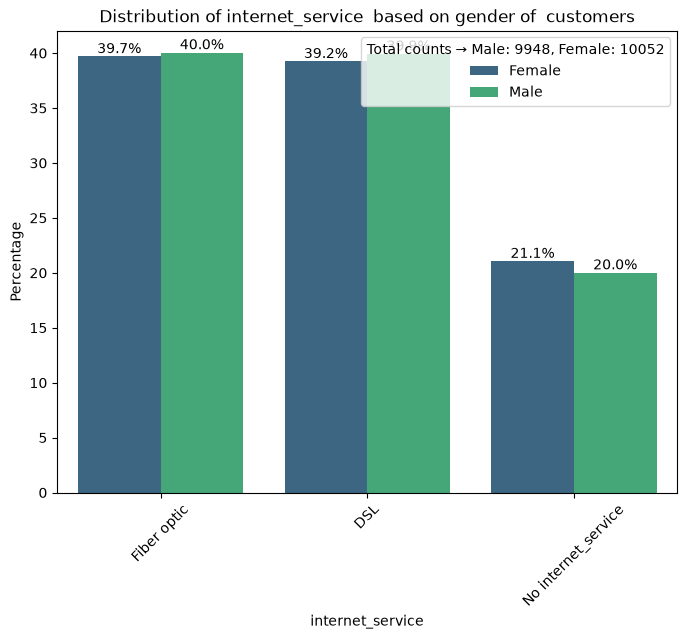

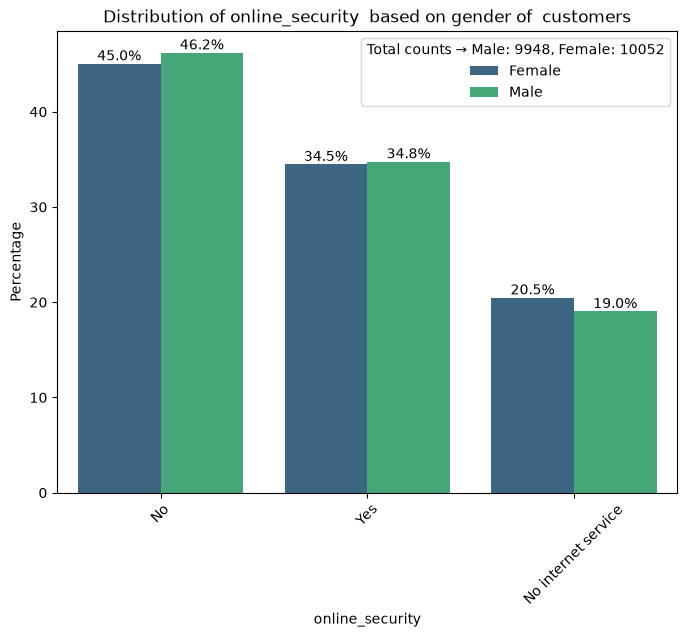

In [15]:
## BIG Question : “Does the distribution of churn‑related features differ by gender?”
#The data is grouped by Gender to anlyse the influence of the other features in the data on the churned customers based on gender

cols_ignore = ["customer_id", "gender","tenure"]   # The columns with high cardinality or not relevant for the analysis
for col in df_clean.columns:
    if col in cols_ignore:
        continue  # Skip the customer_id and gender columns
    else:

        #calculating the percentage of distribution for each column
        percentages = (df_clean.groupby('gender')[col].value_counts(normalize=True) * 100).reset_index()
        percentages.columns = ["gender",col, "Percentage"]
            #plottng the bar graphs
        plt.figure(figsize=(8,6))
        ax=sns.barplot(x=col, y="Percentage", data=percentages,  hue='gender',palette="viridis")
        plt.title(f"Distribution of {col}  based on gender of  customers")
        plt.ylabel("Percentage")
        plt.xlabel(col)
    
        #Adding the percentage values on top of the bars
            
        for container in ax.containers:
                 ax.bar_label(container, fmt="%.1f%%")

        plt.xticks(rotation=45)
 
    # Step 4: Add legend with counts
        male_customers=df_clean[df_clean["gender"] == "Male"]
        female_customers=df_clean[df_clean["gender"] == "Female"]
        plt.legend(
        title=(f'Total counts → Male: {male_customers.shape[0]}, Female: {female_customers.shape[0]}'),
    
        loc='upper right'
    )
    
  






In [16]:
 
from scipy.stats import chi2_contingency

def test_significance(df, group_col="gender", categories=[]):
    results = {}
    for category in categories:
        contingency = pd.crosstab(df[group_col], df[category])# Creates a contingency table (cross-tabulation) of the counts of observations for each combination of the group_col and category. This table is used to perform statistical tests to determine if there is a significant association between the two categorical variables.
        
        if df[category].nunique() == 2:  # binary variable → Z-test of proportions good for binary comparissions of significatnce

            counts = contingency.iloc[:,0].values #the counts of 1 category

            totals = contingency.sum(axis=1).values # For each group (e.g male or female if group_col is "gender" or seniority(senior or non senior)), it calculates the total number of observations

            zstat, pval = sm.stats.proportions_ztest(counts, totals)# runs a two proportion test to determine if the proportions of the two groups are significantly different

            results[category] = ('Z-test', pval)# adds a dictionery of the results of the test and the p-value for each category

        else:  # multi-category → Chi-square

            chi2, p, _, _ = chi2_contingency(contingency)# runs a Chi-square test of independence to determine if there is a significant association between the group_col and the category. The p-value indicates the probability of observing the data if there were no association between the variables.
            results[category] = ('Chi-square', p)# adds a dictionery of the results of the test and the p-value for each category
    return results

# Test the significance of each category
categories = df_clean.columns.tolist()  # add all your churn features
results = test_significance(df, 'gender', categories) #COSTOM FUNCTION  whch takes df ,group_col gender and the list of categories to test for significance

for category, (test, pval) in results.items():
    if pval < 0.05: # if the pvalue is less than 0,005 it means that there is a significant difference in the distribution of the category based on group_ which can be gender or any other group of your choise
        print(f"{category}: {test} p-value = {pval:.4f} (Significant)")
    else: 
        print(f"{category}: {test} p-value = {pval:.4f}")


customer_id: Chi-square p-value = 0.3640
gender: Chi-square p-value = 0.0000 (Significant)
senior_citizen: Chi-square p-value = 0.0083 (Significant)
partner: Chi-square p-value = 0.1113
dependents: Chi-square p-value = 0.5376
tenure: Chi-square p-value = 0.0005 (Significant)
phone_service: Chi-square p-value = 0.4236
multiple_lines: Chi-square p-value = 0.9577
internet_service: Chi-square p-value = 0.6655
online_security: Chi-square p-value = 0.4100


In [17]:

print(percentages)

   gender      online_security  Percentage
0  Female                   No   45.045762
1  Female                  Yes   34.480700
2  Female  No internet service   20.473538
3    Male                   No   46.200241
4    Male                  Yes   34.760756
5    Male  No internet service   19.039003


#The analysis of the gender based churn and how it influenced by the other features available .The Above code cells are where the Telecommunication data  was grouped according to the Gender of the customers.In all of the illastrations above show the distribution of female and male customers in the categories studied. for each Column :['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure', 'phone_service', 'multiple_lines', 'internet_service', 'online_security'], the categories or distinct values represented in each  has the percentage of females out of all the female customers in the data set and same phenominon for males.#

***KEEP NOTE THE TOTAL COUNT FOR EACH : FEMALE(10052) & MALE(9948) IN THE WHOLE DATA SET
AND THE PERCENTAGES OR PROPORTIONS ARE 50.3% & 49.7% RESPECTVELY.***

Overall gender difference: Statistically significant (p = 0.0000). Male and female customers show different patterns in the dataset.

Age (senior citizen status): Significant (p = 0.0083). Older customers churn differently across genders.

Tenure (length of subscription): Significant (p = 0.0005). Subscription length influences churn differently for males vs females.

Other features (partner, dependents, phone service, multiple lines, internet service, online security): Not significant. These do not explain gender‑specific churn differences


*** Does the distribution of churn‑related features differ by gender? Answer :YES BUT MAINLY TENURE AND SENIORITY  DRIVING GENDER BASED CHURN*** 









*** Females and males show different Patterns as indicated above *** 
The further anlysis into the feaatures that indicated  significant difference in Seniority (customers aged 60 or 65 and older) AND SUBSCRPTION LENGTH.

**Gender-Stratified Analysis** -where  i analyse (seniority vs. services graphs) on both genders separately to compare the differences.

In [19]:
#a function that will create interactive visualizations for customer segmentation based on seniority and service usage.
def plot_service_by_seniority(data, service_col, gender_label=None):
    """
    Create an interactive grouped bar chart showing service usage proportions
    by seniority (0=Non-Senior, 1=Senior).
    
    Parameters:
    -----------
    data : pd.DataFrame
        The dataset (already filtered by gender if needed).
    service_col : str
        The service column to analyze (e.g., 'internet_service').
    gender_label : str, optional
        Label for gender (e.g., 'Male' or 'Female') to add context in the chart.
    """
    
    # 1. Build contingency table (counts)
    contingency = pd.crosstab(data['senior_citizen'], data[service_col])#creates the frequency tabel dor each service based on the seniority of the customers in the male or female
    
    # 2. Convert counts to percentages
    percentages = contingency.div(contingency.sum(axis=1), axis=0) * 100# converts counts into percentages based on the total number of senior or non senior
    
    # 3. Reshape for plotting
    percentages = percentages.reset_index().melt(
        id_vars='senior_citizen',
        var_name='service',
        value_name='percentage'
    )
    
    # 4. Calculate totals for annotation
    total_non_senior = data_gender[data_gender['senior_citizen'] == "No"].shape[0]
    total_senior = data_gender[data_gender['senior_citizen'] == "Yes"].shape[0]

    
    
    # 5. Plot interactive grouped bar chart
    fig = px.bar(
        percentages,
        x="service",
        y="percentage",
        color="senior_citizen",
        barmode="group",
        title=f"{service_col} by {data_gender['gender'].unique()[0]} Seniority , non_senior= {total_non_senior}, senior= {total_senior}",
        labels=(f"senior_citizen:","percentage:Percentage (%)","service:",service_col)
    )
    
    fig.show()


In [ ]:

import plotly.express as px
from IPython.display import display
import ipywidgets as widgets

# Now look at the Seneiority of different genders and the services that are offered by the network

services=['phone_service', 'multiple_lines', 'internet_service', 'online_security']
#1.The subset of the gender-specific data frames
df_male = df_clean[df_clean['gender'] == 'Male']
df_female=df_clean[df_clean['gender'] == 'Female']


dfs=[df_male,df_female]
for data_gender in dfs:
    for service_col in services:
        plot_service_by_seniority(data_gender, service_col)


**Integrated Insight  
Building on the earlier gender-based exploration, the extended analysis confirmed that most service-related features—such as partner status, dependents, phone service, multiple lines, internet service, and online security—remain evenly distributed across male and female customers, even when broken down by seniority. These checks were important to validate that the apparent similarities in the charts were not masking hidden differences. The statistical tests reinforced this, showing that the real distinctions emerge through senior citizen status and tenure, which consistently drive the observed gender-based variation. In other words, while service adoption patterns are stable across groups, the demographic dimension of age and the behavioral dimension of subscription length are the true differentiators. This progression from broad distributions to significance testing and subgroup analysis strengthens the narrative: gender differences exist, but they are explained primarily through seniority and tenure rather than service usage. Furthermore, the interaction analysis revealed that some features can be coupled to potentially increase predictive power—for example, combining phone service with multiple lines or internet add‑ons may highlight deeper behavioral patterns that improve churn prediction.**

**TENURE target analysis and feature analysis (demographic and service)**



In [23]:
#tenure sumary statisics
stats=df_clean['tenure'].describe()
print(stats)

count    19929.000000
mean        36.017713
std         22.505054
min          0.000000
25%         17.000000
50%         36.000000
75%         54.000000
max        198.000000
Name: tenure, dtype: float64


Summary stats interpretations 
* on average  customers stayed with the network for 3 years  before churn  but within the group that churned there is  wide variability which means some churned quickly  yet others churned later after many many years.0 month -these are hugh risk individuals which churned immediately after joining.25%the first quater they had less than 17 months  half of the  , 1.5 yrs. 50% of the customers had left the network  before 3 years while 75% churned 4.5 years . truly customers that are 25% of 2000  which are provide more longterm and loyal customer base of the network which are driving the company's  stability  are less likely to churn. there fore the the growth indicator of this network is to delay churn of the groups that churn at more than 17 monts to save cost from chasing high cost and high risk new users as a layer of strategy also providing add on services as loyalty ponts driving service adoption in thos groups while making the customers feel valued and seen . to still have room for growth promote family or coplans  which will bring new customers while retaining the old ones.

***Revenue leakage: Losing customers at 36 months caps growth.***

***High acquisition costs: Constantly replacing churned customers erodes margins.***

***Competitive vulnerability: Competitors with better retention strategies will capture market share.***

Most businesses face the highest churn risk in the first 12 months, often due to poor onboarding or unmet expectations.
Between 12–36 months, churn is typically driven by service dissatisfaction, pricing, or competition.
After 36 months, customers are more stable, but loyalty can erode if competitors offer better value.
For healthy revenue growth, companies should aim to extend average tenure beyond 54 months and predict churn 60–90 days in advance to intervene effectively.

In [24]:
##Discretizing the tenure column into bins for better analysis and visualization
bins = [0, 12, 36, 54, 200]   # cutoff points
labels = ['0-12', '13-36', '37-54', '55+']

df['TenureBin'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=True)

# Check distribution
